In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import os
os.chdir(r"D:\code\github\strainOptimizer")

In [2]:
# set the font size of the figure
plt.rcParams['font.family'] = 'Arial'
# plt.rcParams['font.size'] = 18
plt.rcParams['axes.linewidth'] = 1

axis_fontdict={'fontsize':9,'fontweight':'bold'}
label_fontdict={'fontsize':10,'fontweight':'bold'}
title_fontdict={'fontsize':12,'fontweight':'bold'}

# colors_set=sns.color_palette('colorblind')
colors_paired=sns.color_palette("Paired")
colors_compare=sns.color_palette('colorblind')
# colors_paired
colors_compare

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [3]:
colors_paired

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

### Figure 4A

In [4]:
# load data
df_distance=pd.read_csv(r'analysis_code\results\wt_vs_mutant_protein_flux_distance.csv',index_col=0)
df_distance.head()


,2-phenylethanol,heme,spermidine,sclareol,fatty
protein,0.465788,-0.121344,0.181627,0.307526,0.280872
protein_distance,9.095774,10.729563,10.331232,9.250087,9.133646
flux,0.340709,0.156641,0.243416,0.314006,0.241815
flux_distance,17.657829,16.137855,15.394572,14.393024,15.007197


p value between flux and protein: 0.0007765743391291666


C:\Users\wangh\AppData\Local\Temp\ipykernel_28444\979556121.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='type',y='distance',data=df_1d,ax=ax,palette=[colors_paired[1],colors_paired[7]],alpha=0.6)
C:\Users\wangh\AppData\Local\Temp\ipykernel_28444\979556121.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Flux level','Protein level'],fontweight='bold',fontsize=10)


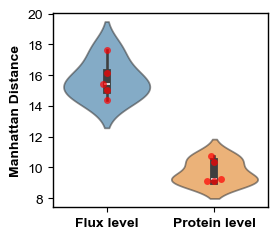

In [29]:
# plot the boxplot the compare the distance 
# df_1d=pd.DataFrame({'distance':df_distance.loc['protein_distance',:].values.tolist()+df_distance.loc['flux_distance',:].values.tolist(),'type':['protein']*len(df_distance.loc['protein_distance',:])+['flux']*len(df_distance.loc['flux_distance',:])})
df_1d=pd.DataFrame({'distance':df_distance.loc['flux_distance',:].values.tolist()+df_distance.loc['protein_distance',:].values.tolist(),'type':['flux']*len(df_distance.loc['flux_distance',:])+['protein']*len(df_distance.loc['protein_distance',:])})
# sns.boxplot(x='type',y='distance',data=df_1d,showfliers=False,)

# calculate the p value
from scipy import stats
flux_distance=df_distance.loc['flux_distance',:].values.tolist()
protein_distance=df_distance.loc['protein_distance',:].values.tolist()
p_value_flux_protein_distance=stats.ttest_rel(flux_distance,protein_distance).pvalue
print(f'p value between flux and protein: {p_value_flux_protein_distance}')
fig,ax=plt.subplots(figsize=(3,2.5))
sns.swarmplot(x='type',y='distance',data=df_1d,color='red',alpha=0.7,ax=ax)
sns.violinplot(x='type',y='distance',data=df_1d,ax=ax,palette=[colors_paired[1],colors_paired[7]],alpha=0.6)
# add the p value as ***
# ax.text(0.5,1.1,f'p value: {p_value_flux_protein_distance:.3f}',ha='center',va='center',fontweight='bold',fontsize=11)
ax.set_xticklabels(['Flux level','Protein level'],fontweight='bold',fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('Manhattan Distance',label_fontdict)
# ax.set_title('Metabolic rewiring between WT and mutant',fontweight='bold',fontsize=12)
# ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig(r'analysis_code\figures\output/figure4a_protein_flux_distance.svg',dpi=600,bbox_inches='tight',transparent=True)
plt.show()

### Figure 4B

In [39]:
# load data
import json
with open(r'analysis_code\results\protein_flux_logfc_distribution.json','r') as f:
    protein_flux_logfc_dict=json.load(f)
flux_logfc=protein_flux_logfc_dict['flux']
protein_logfc=protein_flux_logfc_dict['protein']

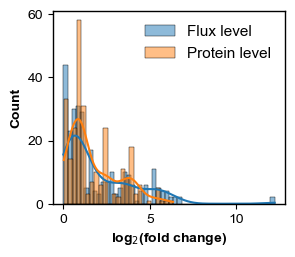

In [40]:
fig,ax=plt.subplots(figsize=(3,2.5))
# sns.kdeplot(flux_logfc,label='flux',fill=True)
# sns.kdeplot(flux_logfc,label='flux',fill=True)
sns.histplot(flux_logfc,kde=True,bins=50,label='Flux level',ax=ax)
sns.histplot(protein_logfc,kde=True,bins=25,label='Protein level',ax=ax)
# set x lim
ax.set_xlabel('log$_2$(fold change)',label_fontdict)
ax.set_ylabel('Count',label_fontdict)
plt.legend(frameon=False,fontsize=11)

# save 
plt.savefig(r'analysis_code\figures\output/figure4b_protein_flux_logfc_distribution.svg',dpi=600,bbox_inches='tight',transparent=True)
plt.show()

In [38]:
# count value > 15
flux_logfc_count=len([i for i in flux_logfc if i>4])
protein_logfc_count=len([i for i in protein_logfc if i>4])
print(f'flux_logfc_count: {flux_logfc_count}, protein_logfc_count: {protein_logfc_count}')


flux_logfc_count: 48, protein_logfc_count: 19


#### distinguish by each product

In [5]:
import json
with open(r'analysis_code\results\protein_flux_logfc_distribution_by_products.json','r') as f:
    products_protein_flux_logfc_dict=json.load(f)

# print all product
print(products_protein_flux_logfc_dict.keys())

dict_keys(['2-phenylethanol', 'heme', 'spermidine', 'sclareol', 'fatty'])


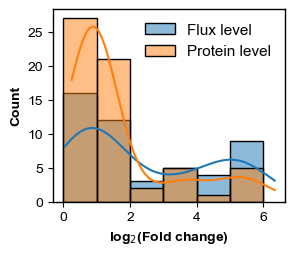

In [34]:
product='2-phenylethanol'
flux_logfc=products_protein_flux_logfc_dict[product]['flux']
protein_logfc=products_protein_flux_logfc_dict[product]['protein']
fig,ax=plt.subplots(figsize=(3,2.5))
# sns.kdeplot(flux_logfc,label='flux',fill=True)
# sns.kdeplot(flux_logfc,label='flux',fill=True)
sns.histplot(flux_logfc,label='Flux level',ax=ax,bins=6,binrange=(0,6),alpha=0.5,kde=True)
sns.histplot(protein_logfc,bins=6,label='Protein level',ax=ax,alpha=0.5,binrange=(0,6),kde=True)
# set x lim
ax.set_xlabel('log$_2$(Fold change)',label_fontdict)
ax.set_ylabel('Count',label_fontdict)
plt.legend(frameon=False,fontsize=11)

# save 
# plt.savefig(r'analysis_code\figures\output/figure4b_protein_flux_logfc_distribution_2PE.svg',dpi=600,bbox_inches='tight',transparent=True)
plt.show()


In [33]:
# count value > 15
flux_logfc_count=len([i for i in flux_logfc if i>4])
protein_logfc_count=len([i for i in protein_logfc if i>4])
print(f'flux_logfc_count: {flux_logfc_count}, protein_logfc_count: {protein_logfc_count}')

flux_logfc_count: 14, protein_logfc_count: 7


### Figure 4D

In [17]:
# load data
df_result=pd.read_csv(r'analysis_code\results/moma_vs_mopa_vs_pfba_vs_ppfba.csv')
# sort by product_name
df_result=df_result.sort_values(by='product_name')
df_result.head()

,model_type,simulation_method,product_name,consistency,precision,predict_num,average_distance,connectivity_score
0,ecGEM,moma,2-phenylethanol,0.750000,0.204545,44,6.484688,9.5
21,GANall,ppfba_GAN,2-phenylethanol,0.666667,0.500000,16,0.000000,0.0
3,ecGEM,ppfba,2-phenylethanol,0.666667,0.228571,35,0.000000,0.0
20,GANall,mopa_GAN,2-phenylethanol,0.666667,0.444444,18,0.000000,0.0
1,ecGEM,mopa,2-phenylethanol,0.750000,0.300000,30,6.277108,18.0


p value of consistency between moma vs mopa: nan, p value of consistency between pfba vs ppfba: 0.06465088719379299
p value of precision between moma vs mopa: 0.40695878314603, p value of precision between pfba vs ppfba: 0.46421399619665477
p value of consistency between moma vs mopa_GAN: 0.5238551529375529, p value of consistency between pfba vs ppfba_GAN: 0.1932059258819597
p value of precision between moma vs mopa_GAN: 0.19725434339262277, p value of precision between pfba vs ppfba_GAN: 0.25741911099180936


C:\Users\wangh\AppData\Local\Temp\ipykernel_28444\588952052.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='simulation_method',y='consistency',data=df_result,ax=axs[0],order=keep_methods,palette=color_dict,errorbar=None)
C:\Users\wangh\AppData\Local\Temp\ipykernel_28444\588952052.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='simulation_method',y='precision',data=df_result,ax=axs[1],legend=False,order=keep_methods,palette=color_dict,errorbar=None)
C:\Users\wangh\AppData\Local\Temp\ipykernel_28444\588952052.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(x_ticks_l

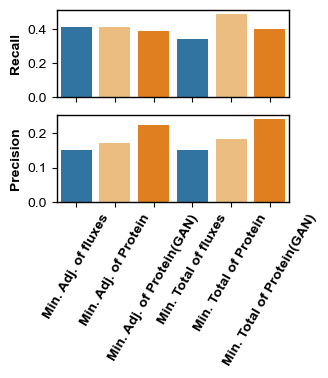

In [18]:
fig,axs=plt.subplots(2,1,figsize=(3,2.5))

x_ticks_dict={'mopa':'Min. Adj. of Protein',
              'moma':'Min. Adj. of fluxes',
              'ppfba':'Min. Total of Protein',
              'pfba':'Min. Total of fluxes',
              'mopa_GAN':'Min. Adj. of Protein(GAN)',
              'ppfba_GAN':'Min. Total of Protein(GAN)',
              'moma_GAN':'Min. Adj. of fluxes(GAN)',
              'pfba_GAN':'Min. Total of fluxes(GAN)',}

keep_methods=['moma','mopa','mopa_GAN','pfba','ppfba','ppfba_GAN']
x_ticks_list=[x_ticks_dict[i] for i in keep_methods]

color_dict={}
for i,item in x_ticks_dict.items():
    if 'Protein' in item:
        color_dict[i]=colors_paired[6]
        if 'GAN' in i:
            color_dict[i]=colors_paired[7]
    else:
        color_dict[i]=colors_paired[1]

# calculate the p value between moma vs mopa, and pfba vs ppfba
import scipy.stats as stats
moma_consistency=df_result[df_result['simulation_method']=='moma']['consistency']
mopa_consistency=df_result[df_result['simulation_method']=='mopa']['consistency']
mopa_GAN_consistency=df_result[df_result['simulation_method']=='mopa_GAN']['consistency']
pfba_consistency=df_result[df_result['simulation_method']=='pfba']['consistency']
ppfba_consistency=df_result[df_result['simulation_method']=='ppfba']['consistency']
ppfba_GAN_consistency=df_result[df_result['simulation_method']=='ppfba_GAN']['consistency']
moma_precision=df_result[df_result['simulation_method']=='moma']['precision']
mopa_precision=df_result[df_result['simulation_method']=='mopa']['precision']
mopa_GAN_precision=df_result[df_result['simulation_method']=='mopa_GAN']['precision']
pfba_precision=df_result[df_result['simulation_method']=='pfba']['precision']
ppfba_precision=df_result[df_result['simulation_method']=='ppfba']['precision']
ppfba_GAN_precision=df_result[df_result['simulation_method']=='ppfba_GAN']['precision']

# calculate the p value with paied values
p_value_moma_mopa_consistency=stats.ttest_rel(moma_consistency,mopa_consistency).pvalue
p_value_moma_mopa_GAN_consistency=stats.ttest_rel(moma_consistency,mopa_GAN_consistency).pvalue
p_value_pfba_ppfba_consistency=stats.ttest_rel(pfba_consistency,ppfba_consistency).pvalue
p_value_pfba_ppfba_GAN_consistency=stats.ttest_rel(pfba_consistency,ppfba_GAN_consistency).pvalue
p_value_moma_mopa_precision=stats.ttest_rel(moma_precision,mopa_precision).pvalue
p_value_moma_mopa_GAN_precision=stats.ttest_rel(moma_precision,mopa_GAN_precision).pvalue
p_value_pfba_ppfba_precision=stats.ttest_rel(pfba_precision,ppfba_precision).pvalue
p_value_pfba_ppfba_GAN_precision=stats.ttest_rel(pfba_precision,ppfba_GAN_precision).pvalue
print(f'p value of consistency between moma vs mopa: {p_value_moma_mopa_consistency}, p value of consistency between pfba vs ppfba: {p_value_pfba_ppfba_consistency}')
print(f'p value of precision between moma vs mopa: {p_value_moma_mopa_precision}, p value of precision between pfba vs ppfba: {p_value_pfba_ppfba_precision}')
print(f'p value of consistency between moma vs mopa_GAN: {p_value_moma_mopa_GAN_consistency}, p value of consistency between pfba vs ppfba_GAN: {p_value_pfba_ppfba_GAN_consistency}')
print(f'p value of precision between moma vs mopa_GAN: {p_value_moma_mopa_GAN_precision}, p value of precision between pfba vs ppfba_GAN: {p_value_pfba_ppfba_GAN_precision}')
# plot Exp consistency
sns.barplot(x='simulation_method',y='consistency',data=df_result,ax=axs[0],order=keep_methods,palette=color_dict,errorbar=None)
# plot the point
# sns.stripplot(x='simulation_method',y='consistency',data=df_result,ax=axs[0],order=keep_methods,color='red',size=5,alpha=1)
# axs[0].set_xticklabels(x_ticks_list,rotation=45,fontweight='bold',fontsize=12)
axs[0].set_xticklabels([])
axs[0].set_xlabel('')
axs[0].set_ylabel('Recall',fontweight='bold',fontsize=10)
# set y lim
# axs[0].set_ylim(0.2,0.5)

sns.barplot(x='simulation_method',y='precision',data=df_result,ax=axs[1],legend=False,order=keep_methods,palette=color_dict,errorbar=None)
# plot the point
# sns.stripplot(x='simulation_method',y='precision',data=df_result,ax=axs[1],legend=False,order=keep_methods,color='red',size=5,alpha=1)
axs[1].set_xticklabels(x_ticks_list,rotation=60,fontweight='bold',fontsize=10)
axs[1].set_xlabel('')
axs[1].set_ylabel('Precision',fontweight='bold',fontsize=10)
# axs[1].set_ylim(0.1,0.2)

# sns.barplot(x='simulation_method',y='average_distance',data=df_result,ax=axs[2],legend=False,order=keep_methods,palette=color_dict,errorbar=None)

# sns.barplot(x='simulation_method',y='connectivity_score',data=df_result,ax=axs[3],legend=False,order=keep_methods,palette=color_dict,errorbar=None)

# save it
# plt.savefig(r'analysis_code\figures\output/figure4_moma_mopa_pfba_ppfba_evaluation.svg',dpi=600,bbox_inches='tight',transparent=True)
plt.show()

In [19]:
# load data
df_all_result=pd.read_csv(r'analysis_code\results\moma_vs_mopa_vs_pfba_vs_ppfba_allproducts_performance.csv',index_col=0)
df_all_result['simulation_method']=df_all_result.index
df_all_result

,consistency,precision,predict_num,simulation_method
moma,0.405405,0.123967,363.0,moma
mopa,0.396396,0.126074,349.0,mopa
pfba,0.387387,0.180672,238.0,pfba
ppfba,0.621622,0.200581,344.0,ppfba
mopa_GANall,0.405405,0.200000,225.0,mopa_GANall
ppfba_GANall,0.405405,0.209302,215.0,ppfba_GANall


C:\Users\wangh\AppData\Local\Temp\ipykernel_28444\1213224697.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='simulation_method',y='consistency',data=df_all_result,ax=axs[0],order=keep_methods,palette=color_dict,errorbar=None)
C:\Users\wangh\AppData\Local\Temp\ipykernel_28444\1213224697.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='simulation_method',y='precision',data=df_all_result,ax=axs[1],legend=False,order=keep_methods,palette=color_dict,errorbar=None)
C:\Users\wangh\AppData\Local\Temp\ipykernel_28444\1213224697.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabel

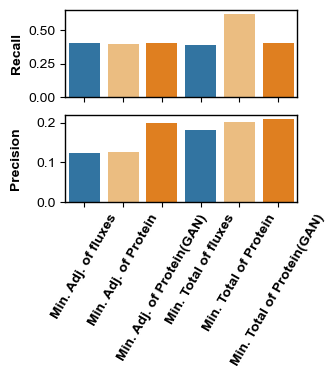

In [20]:
fig,axs=plt.subplots(2,1,figsize=(3,2.5))

x_ticks_dict={'mopa':'Min. Adj. of Protein',
              'moma':'Min. Adj. of fluxes',
              'ppfba':'Min. Total of Protein',
              'pfba':'Min. Total of fluxes',
              'mopa_GANall':'Min. Adj. of Protein(GAN)',
              'ppfba_GANall':'Min. Total of Protein(GAN)',
              'moma_GANall':'Min. Adj. of fluxes(GAN)',
              'pfba_GANall':'Min. Total of fluxes(GAN)',}

keep_methods=['moma','mopa','mopa_GANall','pfba','ppfba','ppfba_GANall']
x_ticks_list=[x_ticks_dict[i] for i in keep_methods]

color_dict={}
for i,item in x_ticks_dict.items():
    if 'Protein' in item:
        color_dict[i]=colors_paired[6]
        if 'GAN' in i:
            color_dict[i]=colors_paired[7]
    else:
        color_dict[i]=colors_paired[1]
# plot Exp consistency
sns.barplot(x='simulation_method',y='consistency',data=df_all_result,ax=axs[0],order=keep_methods,palette=color_dict,errorbar=None)
# plot the point
# sns.stripplot(x='simulation_method',y='consistency',data=df_result,ax=axs[0],order=keep_methods,color='red',size=5,alpha=1)
# axs[0].set_xticklabels(x_ticks_list,rotation=45,fontweight='bold',fontsize=12)
axs[0].set_xticklabels([])
axs[0].set_xlabel('')
axs[0].set_ylabel('Recall',fontweight='bold',fontsize=10)
# set y lim
# axs[0].set_ylim(0.2,0.5)

sns.barplot(x='simulation_method',y='precision',data=df_all_result,ax=axs[1],legend=False,order=keep_methods,palette=color_dict,errorbar=None)
# plot the point
# sns.stripplot(x='simulation_method',y='precision',data=df_result,ax=axs[1],legend=False,order=keep_methods,color='red',size=5,alpha=1)
axs[1].set_xticklabels(x_ticks_list,rotation=60,fontweight='bold',fontsize=10)
axs[1].set_xlabel('')
axs[1].set_ylabel('Precision',fontweight='bold',fontsize=10,labelpad=10)
# axs[1].set_ylim(0.1,0.2)

# sns.barplot(x='simulation_method',y='average_distance',data=df_result,ax=axs[2],legend=False,order=keep_methods,palette=color_dict,errorbar=None)

# sns.barplot(x='simulation_method',y='connectivity_score',data=df_result,ax=axs[3],legend=False,order=keep_methods,palette=color_dict,errorbar=None)

# save it
plt.savefig(r'analysis_code\figures\output/figure4_moma_mopa_pfba_ppfba_evaluation.svg',dpi=600,bbox_inches='tight',transparent=True)
plt.show()

### Supplementary figure

In [14]:
# load data
df_result=pd.read_csv(r'analysis_code\results/moma_vs_mopa_vs_pfba_vs_ppfba.csv')
# sort by product_name
df_result=df_result.sort_values(by='product_name')
df_result.head()

,model_type,simulation_method,product_name,consistency,precision,predict_num,average_distance,connectivity_score
0,ecGEM,moma,2-phenylethanol,0.750000,0.204545,44,6.484688,9.5
21,GANall,ppfba_GAN,2-phenylethanol,0.666667,0.500000,16,0.000000,0.0
3,ecGEM,ppfba,2-phenylethanol,0.666667,0.228571,35,0.000000,0.0
20,GANall,mopa_GAN,2-phenylethanol,0.666667,0.444444,18,0.000000,0.0
1,ecGEM,mopa,2-phenylethanol,0.750000,0.300000,30,6.277108,18.0


C:\Users\wangh\AppData\Local\Temp\ipykernel_32252\1254682403.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(rotation=0,labels=x_ticks_list,fontweight='bold',fontsize=12)


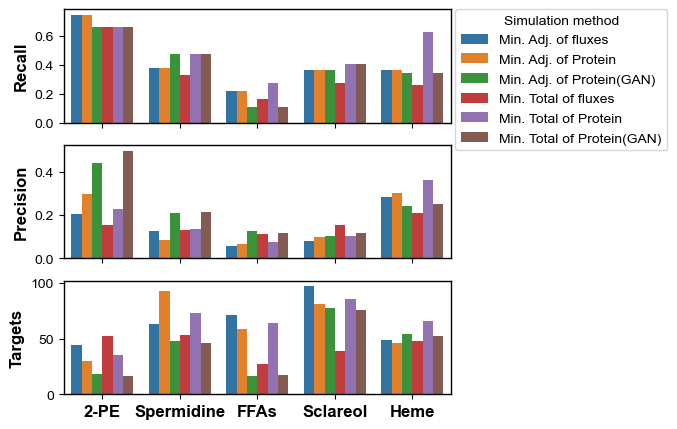

In [15]:
method_dict={'mopa':'Min. Adj. of Protein',
              'moma':'Min. Adj. of fluxes',
              'ppfba':'Min. Total of Protein',
              'pfba':'Min. Total of fluxes',
              'mopa_GAN':'Min. Adj. of Protein(GAN)',
              'ppfba_GAN':'Min. Total of Protein(GAN)',
              'moma_GAN':'Min. Adj. of fluxes(GAN)',
              'pfba_GAN':'Min. Total of fluxes(GAN)',}

df=df_result.copy()
df['simulation_method']=df['simulation_method'].map(method_dict)


# plot the barplots for consistency, accuracy and predict num and hue by simulation method
fig,axs=plt.subplots(3,1,figsize=(5,5))

product_name_order ={'2-phenylethanol':0,'spermidine':1,'ffa':2,'sclareol':3,'heme':4}
keep_methods=['moma','mopa','mopa_GAN','pfba','ppfba','ppfba_GAN']
keep_methods=[method_dict[i] for i in keep_methods]
# plot experiment constency
sns.barplot(x='product_name',y='consistency',hue='simulation_method',data=df,ax=axs[0],order=product_name_order.keys(),hue_order=keep_methods)
# remove x tick and label
axs[0].set_xticklabels([])
axs[0].set_xlabel('')
axs[0].set_ylabel('Recall',fontweight='bold',fontsize=12)
# set legend outside 
axs[0].legend(title='Simulation method',bbox_to_anchor=(1.01, 1), borderaxespad=0.)

# plot experiment accuracy
sns.barplot(x='product_name',y='precision',hue='simulation_method',data=df,ax=axs[1],legend=False,order=product_name_order.keys(),hue_order=keep_methods)
# remove x tick and label
axs[1].set_xticklabels([])
axs[1].set_xlabel('')
axs[1].set_ylabel('Precision',fontweight='bold',fontsize=12)


# plot experiment predict num
sns.barplot(x='product_name',y='predict_num',hue='simulation_method',data=df,ax=axs[2],legend=False,order=product_name_order.keys(),hue_order=keep_methods)
# set x, y ticks
# set x ticks
x_ticks_dict={'2-phenylethanol':'2-PE',
              'heme':'Heme',
              'ffa':'FFAs',
              'sclareol':'Sclareol',
              'spermidine':'Spermidine'}
x_ticks_list=[x_ticks_dict[i] for i in product_name_order.keys()]
axs[2].set_xticklabels(rotation=0,labels=x_ticks_list,fontweight='bold',fontsize=12)
axs[2].set_xlabel('')
axs[2].set_ylabel('Targets',fontweight='bold',fontsize=12)

# SAVE 
plt.savefig(r'analysis_code\figures\output/figureS5_moma_mopa_pfba_ppfba_evaluation_each_product.svg',dpi=600,bbox_inches='tight',transparent=True)
plt.show()